# Klasifikasi Otomatis Pengaduan Layanan TI
TF-IDF + Multinomial Naive Bayes

In [61]:
!pip -q install pandas scikit-learn matplotlib

In [62]:
    import pandas as pd
    from sklearn.model_selection import train_test_split
    from sklearn.pipeline import Pipeline
    from sklearn.feature_extraction.text import TfidfVectorizer
    from sklearn.naive_bayes import MultinomialNB
    from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [63]:
from google.colab import files
uploaded = files.upload()
df = pd.read_csv('dataset_pengaduan_ti.csv')
df.head()

Saving dataset_pengaduan_ti.csv to dataset_pengaduan_ti (5).csv


,pengaduan,kategori
0,"Permisi, Software komputer ruang kelas tidak b...",Software
1,Saya melaporkan bahwa Perangkat saya tidak bis...,Jaringan
2,"Permisi, Word di komputer gedung perkuliahan m...",Software
3,"Mohon bantuan, Data KHS di akun saya belum dip...",Sistem Akademik
4,"Tolong, SIAKAD tidak bisa dibuka saat saya mem...",Sistem Akademik


In [64]:
print(df.shape)
print(df['kategori'].value_counts())

(500, 2)
kategori
Software           100
Jaringan           100
Sistem Akademik    100
Akun & Akses       100
Hardware           100
Name: count, dtype: int64


In [65]:
X_train, X_test, y_train, y_test = train_test_split(df['pengaduan'], df['kategori'], test_size=0.20, random_state=42, stratify=df['kategori'])

In [66]:
model = Pipeline([('tfidf', TfidfVectorizer(lowercase=True, ngram_range=(1,2), sublinear_tf=True)), ('classifier', MultinomialNB(alpha=0.5))])
model.fit(X_train, y_train)

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(ngram_range=(1, 2), sublinear_tf=True)),
                ('classifier', MultinomialNB(alpha=0.5))])

In [67]:
prediksi = model.predict(X_test)
print('Akurasi:', accuracy_score(y_test, prediksi))
print(classification_report(y_test, prediksi))

Akurasi: 1.0
                 precision    recall  f1-score   support

   Akun & Akses       1.00      1.00      1.00        20
       Hardware       1.00      1.00      1.00        20
       Jaringan       1.00      1.00      1.00        20
Sistem Akademik       1.00      1.00      1.00        20
       Software       1.00      1.00      1.00        20

       accuracy                           1.00       100
      macro avg       1.00      1.00      1.00       100
   weighted avg       1.00      1.00      1.00       100



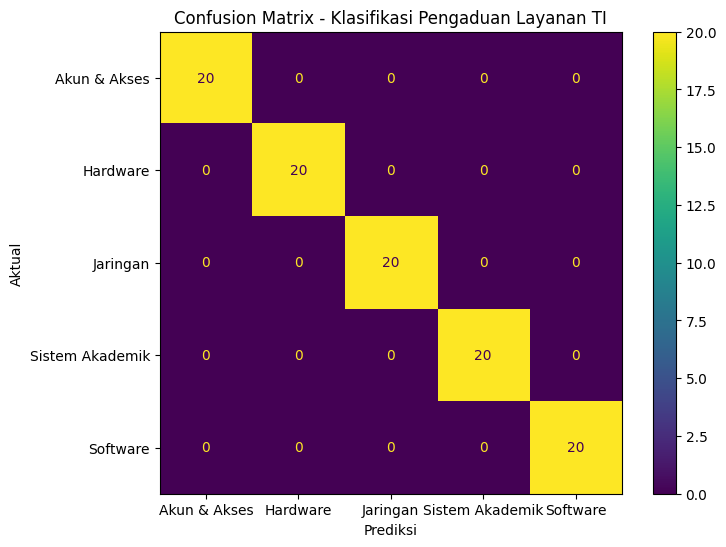

In [68]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Membuat confusion matrix
cm = confusion_matrix(y_test, prediksi)

# Menampilkan confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=model.classes_
)

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax)

plt.title("Confusion Matrix - Klasifikasi Pengaduan Layanan TI")
plt.xlabel("Prediksi")
plt.ylabel("Aktual")
plt.show()

In [69]:
# Pengujian dengan data pengaduan baru

data_baru = [
    "Internet kampus sangat lambat ketika digunakan untuk mengakses website",
    "Saya gagal melakukan pengisian KRS di sistem akademik",
    "Keyboard komputer laboratorium tidak berfungsi",
    "Microsoft Word di komputer kampus sering mengalami error",
    "Saya tidak dapat login karena password akun kampus tidak diterima",
    "Koneksi WiFi di ruang kelas sering hilang",
    "Nilai mata kuliah belum muncul di KHS saya",
    "Layar monitor komputer di laboratorium berwarna hitam",
    "Aplikasi yang saya gunakan tiba-tiba berhenti sendiri",
    "Saya lupa password akun mahasiswa dan tidak bisa masuk"
]

for teks in data_baru:
    hasil = model.predict([teks])[0]
    print("Pengaduan :", teks)
    print("Prediksi   :", hasil)
    print("-" * 60)

Pengaduan : Internet kampus sangat lambat ketika digunakan untuk mengakses website
Prediksi   : Jaringan
------------------------------------------------------------
Pengaduan : Saya gagal melakukan pengisian KRS di sistem akademik
Prediksi   : Sistem Akademik
------------------------------------------------------------
Pengaduan : Keyboard komputer laboratorium tidak berfungsi
Prediksi   : Hardware
------------------------------------------------------------
Pengaduan : Microsoft Word di komputer kampus sering mengalami error
Prediksi   : Software
------------------------------------------------------------
Pengaduan : Saya tidak dapat login karena password akun kampus tidak diterima
Prediksi   : Akun & Akses
------------------------------------------------------------
Pengaduan : Koneksi WiFi di ruang kelas sering hilang
Prediksi   : Jaringan
------------------------------------------------------------
Pengaduan : Nilai mata kuliah belum muncul di KHS saya
Prediksi   : Sistem Akademi

In [70]:
# Distribusi dataset berdasarkan kategori

distribusi = df['kategori'].value_counts()

print("Distribusi Data Pengaduan:")
print(distribusi)

print("\nTotal data:", len(df))

Distribusi Data Pengaduan:
kategori
Software           100
Jaringan           100
Sistem Akademik    100
Akun & Akses       100
Hardware           100
Name: count, dtype: int64

Total data: 500


In [71]:
# Distribusi dataset berdasarkan kategori

distribusi = df['kategori'].value_counts()

print("Distribusi Data Pengaduan:")
print(distribusi)

print("\nTotal data:", len(df))

Distribusi Data Pengaduan:
kategori
Software           100
Jaringan           100
Sistem Akademik    100
Akun & Akses       100
Hardware           100
Name: count, dtype: int64

Total data: 500


In [72]:
labels=sorted(df['kategori'].unique())
print(pd.DataFrame(confusion_matrix(y_test,prediksi,labels=labels),index=labels,columns=labels))

                 Akun & Akses  Hardware  Jaringan  Sistem Akademik  Software
Akun & Akses               20         0         0                0         0
Hardware                    0        20         0                0         0
Jaringan                    0         0        20                0         0
Sistem Akademik             0         0         0               20         0
Software                    0         0         0                0        20


In [73]:
def prediksi_pengaduan(teks):
    hasil=model.predict([teks])[0]
    print('Pengaduan:',teks)
    print('Kategori :',hasil)

prediksi_pengaduan('WiFi di gedung baru sering terputus')
prediksi_pengaduan('Saya tidak bisa melakukan pengisian KRS')
prediksi_pengaduan('Monitor komputer lab tidak menyala')
prediksi_pengaduan('Aplikasi Excel tiba tiba tertutup')
prediksi_pengaduan('Password akun kampus saya ditolak')

Pengaduan: WiFi di gedung baru sering terputus
Kategori : Jaringan
Pengaduan: Saya tidak bisa melakukan pengisian KRS
Kategori : Sistem Akademik
Pengaduan: Monitor komputer lab tidak menyala
Kategori : Hardware
Pengaduan: Aplikasi Excel tiba tiba tertutup
Kategori : Software
Pengaduan: Password akun kampus saya ditolak
Kategori : Akun & Akses
